In [40]:
from matplotlib import pyplot
import nibabel
import seaborn
import numpy
import pandas
import scipy.signal

In [2]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [3]:
!pwd

/home/elth11/SpaceMed-2026/elth11/src/spacemed


%cd ../.. (Move up two folders from where I am right now.)

In [4]:
%cd /home/elth11/SpaceMed-2026/elth11/data

/home/elth11/SpaceMed-2026/elth11/data


In [5]:
anatomy = nibabel.load("fmri-data/2_Anatomy_1mm_5min.nii")

In [6]:
print(anatomy.header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 192 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.       1.       0.976562 0.976562 2.3      0.       0.       0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=2.3;Time=170738.945'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.027891552075743675
quatern_c       : 0.006216157227754593
quatern_d       : -0.0195028111338615

In [7]:
print(anatomy.shape)

(192, 256, 256)


In [8]:
print(anatomy.header.get_zooms())

(np.float32(1.0), np.float32(0.976562), np.float32(0.976562))


In [9]:
data_anatomy = anatomy.get_fdata()

T transposes x with y, origin="lower" makes the beginning bottom left (turning the image); 120 to begin, 96 middle of dataset)
[120, :, :] [96, :, :] [ :, 120, :]

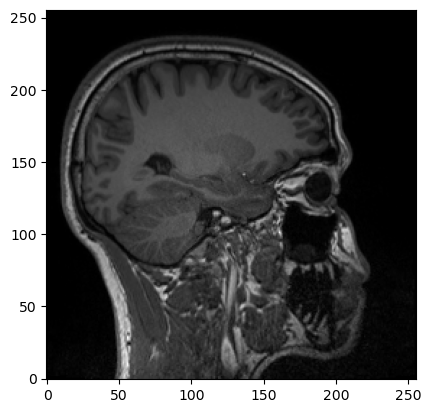

In [10]:
fig, axes = pyplot.subplots(1)
axes.imshow(data_anatomy[120, :, :].T,
    origin="lower",
    cmap="gray")

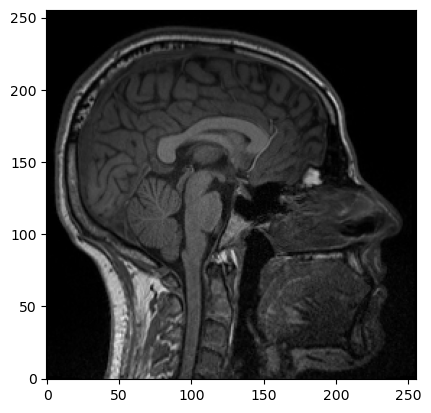

In [11]:
fig, axes = pyplot.subplots(1)
axes.imshow(data_anatomy[96, :, :].T,
    origin="lower",
    cmap="gray")

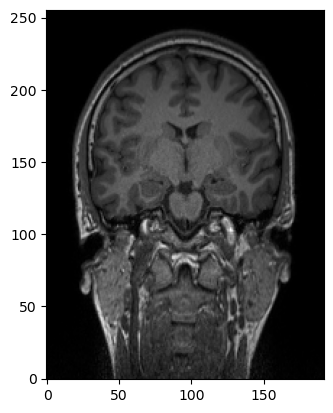

In [12]:
fig, axes = pyplot.subplots(1)
axes.imshow(data_anatomy[ :, 120, :].T,
    origin="lower",
    cmap="gray")

In [13]:
print(anatomy.affine)

[[ 9.99162018e-01  3.77299786e-02  1.31960846e-02 -9.83170929e+01]
 [-3.93290296e-02  9.74299788e-01  5.42062148e-02 -1.24112167e+02]
 [-1.13369459e-02 -5.46798818e-02  9.74967122e-01 -1.17133888e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [14]:
ols = pandas.read_csv("../data/session8data/ols.csv")

In [15]:
ols

,Vehicle,Length (m),Payload Mass to LEO (kg),Origin,First Flight,Initial Mass (kg)
0,Falcon 9,70.00,22800,USA,2010.0,549000
1,Falcon Heavy,70.00,63800,USA,2018.0,1420000
2,Atlas V,62.50,13550,USA,2002.0,335000
3,Delta IV Heavy,72.00,28370,USA,2002.0,733000
4,SLS Block 1,98.00,95000,USA,2022.0,2600000
5,Starship,120.00,125000,USA,2024.0,5000000
6,Vulcan Centaur,61.00,27200,USA,2023.0,540000
7,Electron,18.00,300,USA,2015.0,12500
8,New Glenn,98.00,45000,USA,2021.0,862000
9,Saturn V,110.60,140000,USA,1967.0,3000000


<Axes: xlabel='Initial Mass (kg)', ylabel='Payload Mass to LEO (kg)'>

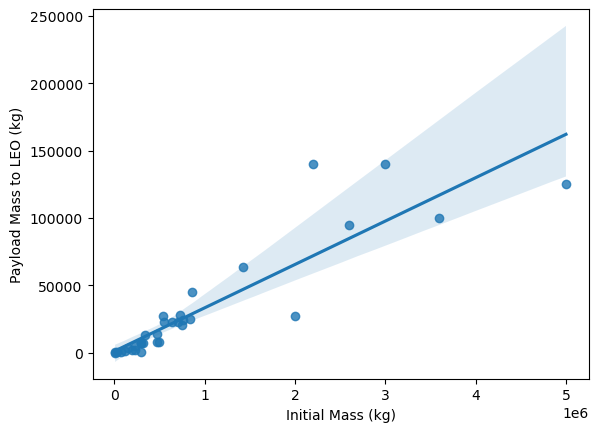

In [16]:
seaborn.regplot(ols,
                x= "Initial Mass (kg)",
                y= "Payload Mass to LEO (kg)",
                order=1)

<Axes: xlabel='Length (m)', ylabel='Payload Mass to LEO (kg)'>

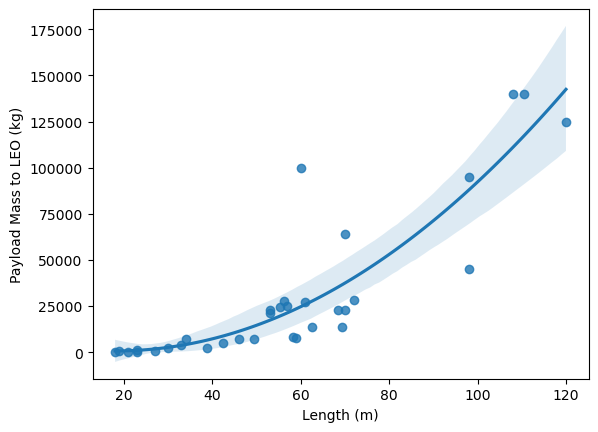

In [17]:
seaborn.regplot(ols,
                x= "Length (m)",
                y= "Payload Mass to LEO (kg)",
                order=2)

In [18]:
fmri = nibabel.load("fmri-data/3_fMRI_TR2sec_3mm_3min.nii")

In [19]:
fmri.shape

(64, 64, 32, 80)

In [20]:
print(fmri.header.get_zooms())

(np.float32(3.0), np.float32(3.0), np.float32(3.75), np.float32(2.0))


In [21]:
nt = fmri.shape[-1] #number of times

In [22]:
sampling_rate = fmri.header.get_zooms()[-1]

In [23]:
print(nt, sampling_rate)

80 2.0


In [37]:
p1 = (19,24,25) #spatial coordinates defined but not time
p2 = (40,25,25)
p3 = (19,25,25)

In [35]:
fmri_data = fmri.get_fdata()

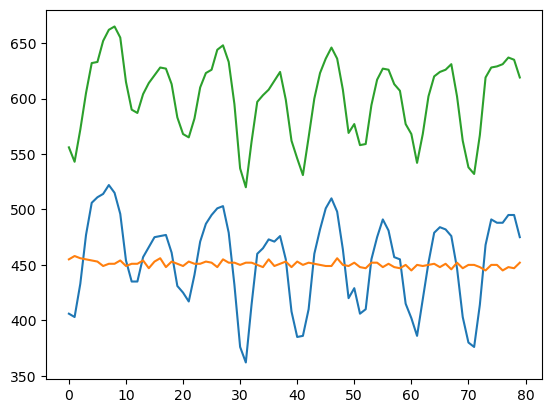

In [38]:
pyplot.plot(fmri_data[p1])
pyplot.plot(fmri_data[p2])
pyplot.plot(fmri_data[p3])

In [28]:
s_one = numpy.array([1]*5 + [0]*5)

In [29]:
s_one

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

In [30]:
nt

80

If nt is not divisable by 10, we round up with numpy.ceil

In [32]:
signal = numpy.tile(s_one, int(numpy.ceil(nt/10))) #tile 2 repeats signal twice

In [33]:
signal = signal[:nt]

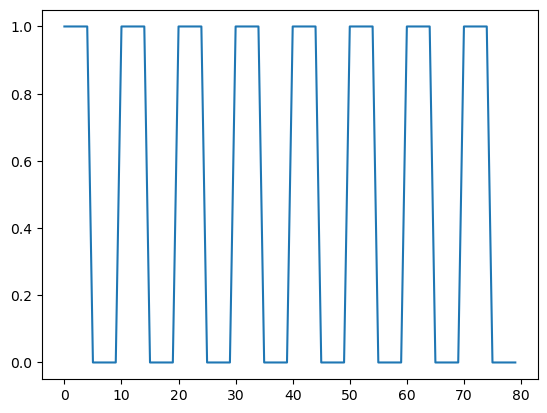

In [34]:
pyplot. plot(signal)

In [39]:
def normalise(data):
    norm = (data - numpy.mean(data))
    norm = norm / numpy.std(data)
    return norm

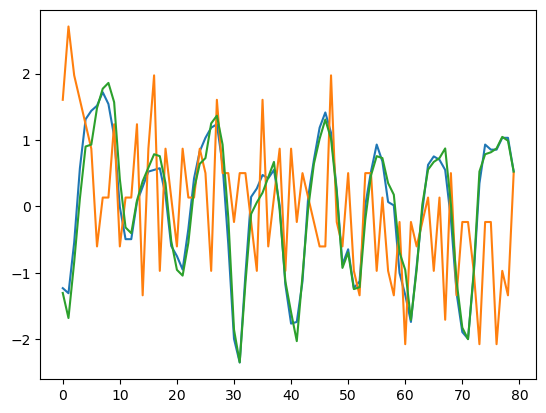

In [41]:
pyplot.plot(normalise(fmri_data[p1]))
pyplot.plot(normalise(fmri_data[p2]))
pyplot.plot(normalise(fmri_data[p3]))

you could also call p i, its just the name of the variable you use to create a list 
(in this case a list with p1-p3)

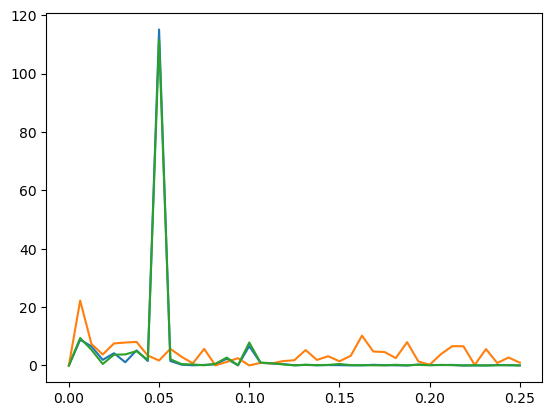

In [44]:
for p in [p1, p2, p3]:
    freq, power = scipy.signal.periodogram(normalise(fmri_data[p]),
                                       fs=1/sampling_rate)
    pyplot.plot(freq, power)

58.11914196096052
11.543840394935287
56.45565951227974


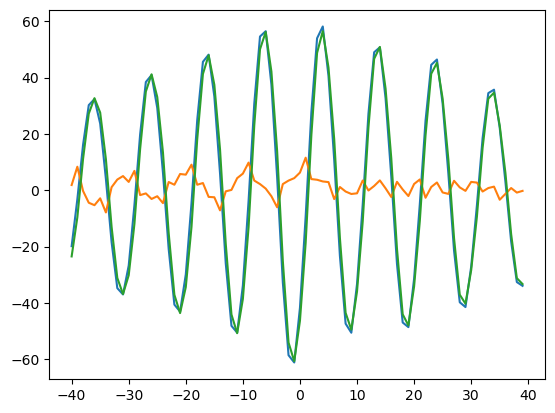

In [54]:
for p in [p1, p2, p3]:
    data = fmri_data[p]
    cross = scipy.signal.correlate(
        normalise(data), normalise(signal),
        mode="same")
    lags = scipy.signal.correlation_lags(
        len(data), len(signal),
        mode="same")
    pyplot.plot(lags, cross)
    c = numpy.max(cross) #Interesting is the maximum of this curve
    print(c)

In [47]:
p = numpy.argmax(cross)

In [48]:
lags[p] #sth happens at 8 sec (reaction of brain blood oxygenation)

np.int64(4)

In [55]:
numpy.zeros(fmri.shape[:2]) #fill this array with cross correlation

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(64, 64))